# Data Visualization & SQL

**Topics covered:**
1. Matplotlib basics
2. Basic charts (line, bar)
3. Histograms
4. Scatter plots
5. Correlation heatmaps (concept)
6. SQL basics — SELECT, WHERE, GROUP BY, JOIN
7. Connecting Python with databases

Type the code yourself, run each cell, and look at the output before moving to the next cell.
Practice questions are at the end of each section.

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

# This makes charts render nicely inside the notebook
%matplotlib inline

print("Matplotlib ready.")

Matplotlib ready.


## 1. Matplotlib Basics

Matplotlib is the foundational plotting library in Python. The core idea: you have a
**Figure** (the whole canvas) containing one or more **Axes** (individual plots).

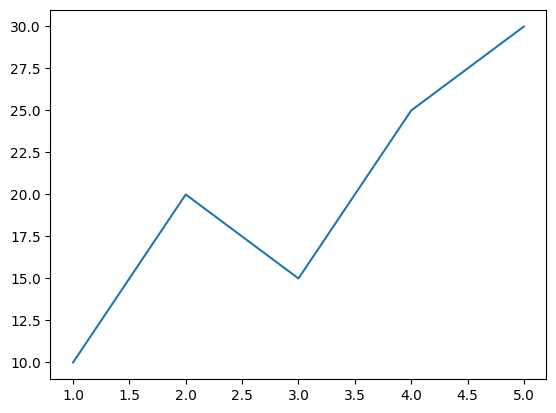

In [2]:
# The simplest possible plot
x = [1, 2, 3, 4, 5]
y = [10, 20, 15, 25, 30]

plt.plot(x, y)
plt.show()

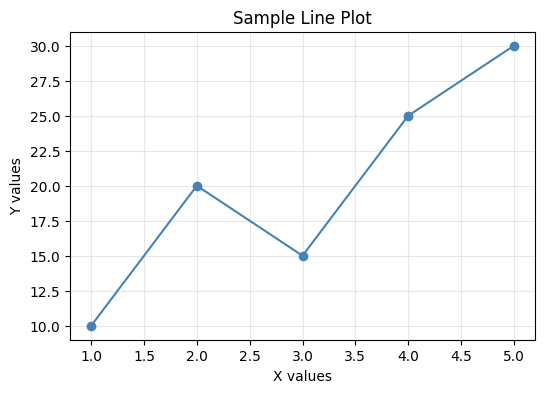

In [3]:
# The same plot, done "properly" with labels and title
# This is the pattern you should use for every chart from now on
fig, ax = plt.subplots(figsize=(6, 4))   # create a figure and one axes
ax.plot(x, y, marker="o", color="steelblue")
ax.set_title("Sample Line Plot")
ax.set_xlabel("X values")
ax.set_ylabel("Y values")
ax.grid(True, alpha=0.3)
plt.show()

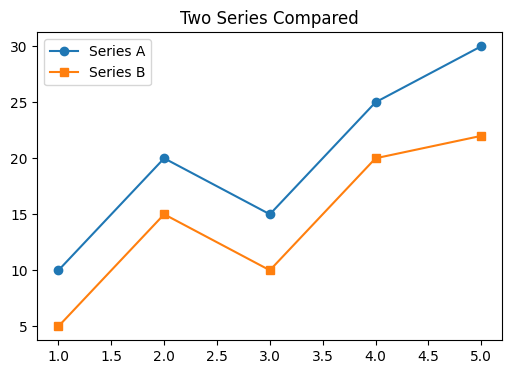

In [4]:
# Multiple lines on one chart, with a legend
y2 = [5, 15, 10, 20, 22]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, y, marker="o", label="Series A")
ax.plot(x, y2, marker="s", label="Series B")
ax.set_title("Two Series Compared")
ax.legend()
plt.show()

**Practice 1**
Plot `y = x**2` for `x` from 0 to 10 (hint: use `np.arange` or `range`), with a title
and axis labels.

In [5]:
# Your practice code here


## 2. Basic Charts — Line & Bar

Let's use a small sales dataset for the rest of the visualization section.

In [6]:
# Sample dataset we'll reuse throughout this notebook
np.random.seed(42)
sales = pd.DataFrame({
    "month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "revenue": [12000, 15000, 11000, 18000, 21000, 19500],
    "units_sold": [120, 150, 100, 175, 210, 195],
    "marketing_spend": [2000, 2500, 1800, 3000, 3500, 3200]
})
sales

,month,revenue,units_sold,marketing_spend
0,Jan,12000,120,2000
1,Feb,15000,150,2500
2,Mar,11000,100,1800
3,Apr,18000,175,3000
4,May,21000,210,3500
5,Jun,19500,195,3200


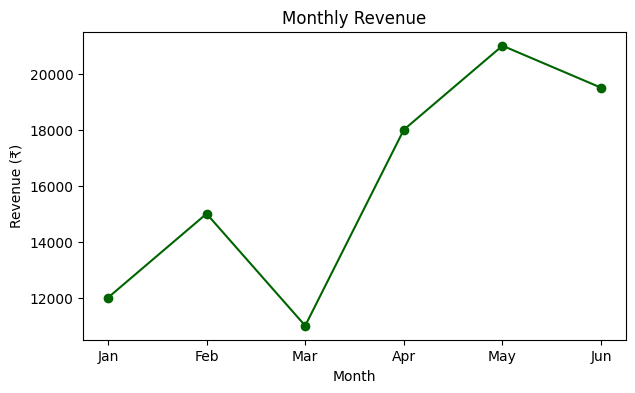

In [7]:
# Line chart: revenue over time -> good for trends
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sales["month"], sales["revenue"], marker="o", color="darkgreen")
ax.set_title("Monthly Revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (₹)")
plt.show()

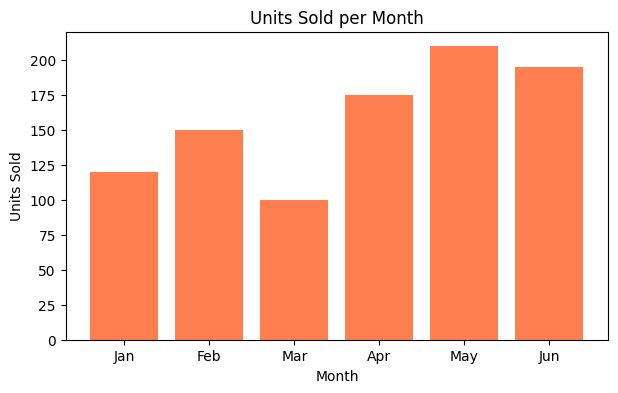

In [8]:
# Bar chart: good for comparing categories
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(sales["month"], sales["units_sold"], color="coral")
ax.set_title("Units Sold per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Units Sold")
plt.show()

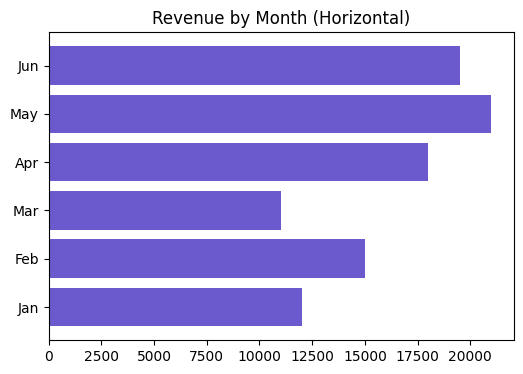

In [9]:
# Horizontal bar chart -> useful when category labels are long
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(sales["month"], sales["revenue"], color="slateblue")
ax.set_title("Revenue by Month (Horizontal)")
plt.show()

**Practice 2**
Make a bar chart of `marketing_spend` per month. Rule of thumb: use a **line** chart for
trends over time, a **bar** chart for comparing discrete categories.

In [10]:
# Your practice code here


## 3. Histograms

A histogram shows the **distribution** of a single numeric variable — how many values fall
into each range ("bin").

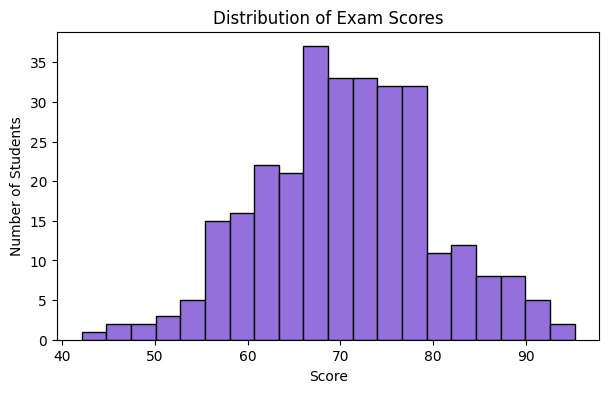

In [11]:
# Generate some random data to visualize (simulating exam scores)
np.random.seed(1)
scores = np.random.normal(loc=70, scale=10, size=300)  # mean=70, std=10, 300 students

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(scores, bins=20, color="mediumpurple", edgecolor="black")
ax.set_title("Distribution of Exam Scores")
ax.set_xlabel("Score")
ax.set_ylabel("Number of Students")
plt.show()

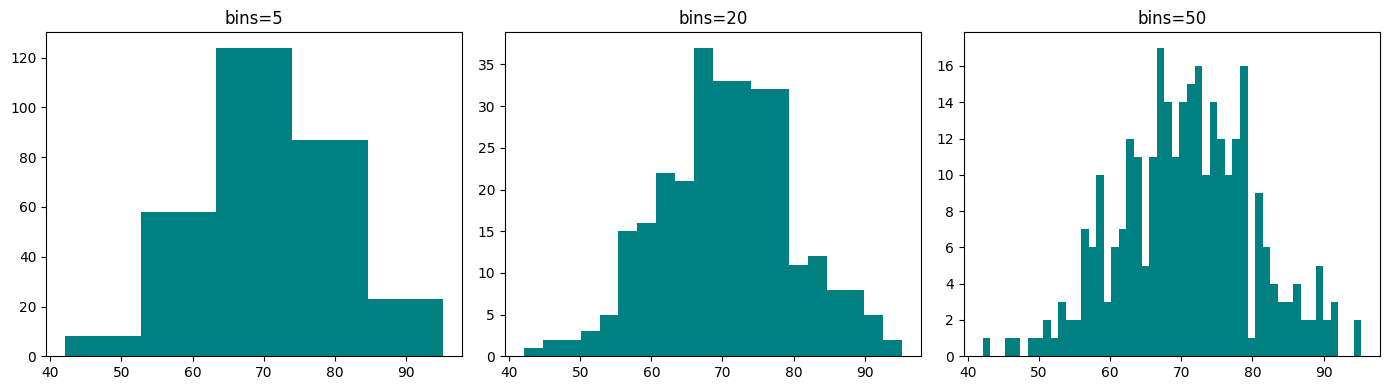

In [12]:
# The 'bins' parameter controls how granular the histogram is - try a few values
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, b in zip(axes, [5, 20, 50]):
    ax.hist(scores, bins=b, color="teal")
    ax.set_title(f"bins={b}")
plt.tight_layout()
plt.show()

**Practice 3**
Generate 500 random values with `np.random.exponential(scale=2, size=500)` and plot a
histogram with 30 bins. How is the shape different from the normal distribution above?

In [13]:
# Your practice code here


## 4. Scatter Plots

A scatter plot shows the relationship between **two** numeric variables — one point per
row of data. Great for spotting correlation, clusters, or outliers.

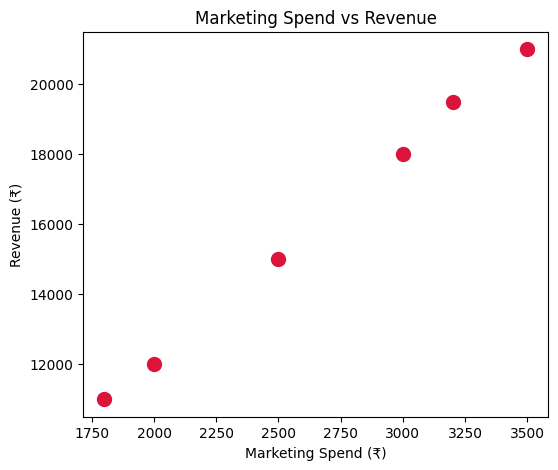

In [14]:
# marketing_spend vs revenue - is there a relationship?
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sales["marketing_spend"], sales["revenue"], s=100, color="crimson")
ax.set_title("Marketing Spend vs Revenue")
ax.set_xlabel("Marketing Spend (₹)")
ax.set_ylabel("Revenue (₹)")
plt.show()

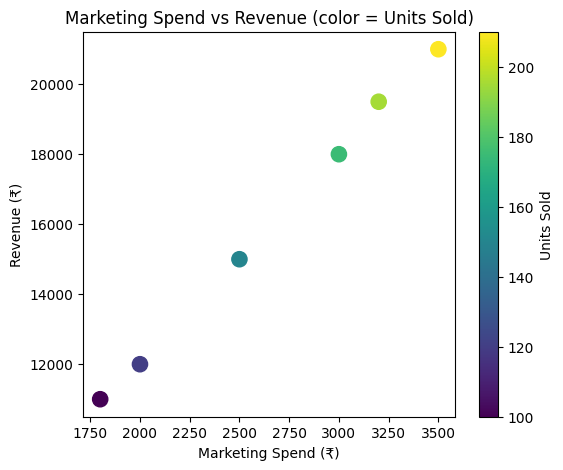

In [15]:
# Scatter plot with color representing a third variable (units_sold)
fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(
    sales["marketing_spend"], sales["revenue"],
    c=sales["units_sold"], cmap="viridis", s=120
)
ax.set_title("Marketing Spend vs Revenue (color = Units Sold)")
ax.set_xlabel("Marketing Spend (₹)")
ax.set_ylabel("Revenue (₹)")
plt.colorbar(scatter, label="Units Sold")
plt.show()

**Practice 4**
Create two random arrays of 100 points each (`np.random.rand(100)`) and make a scatter
plot of them. Since the data is random, what pattern (or lack of pattern) do you expect
to see?

In [16]:
# Your practice code here


## 5. Correlation Heatmaps (Concept)

A correlation heatmap shows, at a glance, how strongly every pair of numeric columns is
related. Values range from -1 (strong negative relationship) to +1 (strong positive
relationship), with 0 meaning no linear relationship.

We'll build one using only Matplotlib (no seaborn needed) so you understand what's
happening underneath.

In [17]:
# Step 1: compute the correlation matrix
numeric_cols = sales[["revenue", "units_sold", "marketing_spend"]]
corr = numeric_cols.corr()
corr

,revenue,units_sold,marketing_spend
revenue,1.000000,0.996362,0.999470
units_sold,0.996362,1.000000,0.996694
marketing_spend,0.999470,0.996694,1.000000


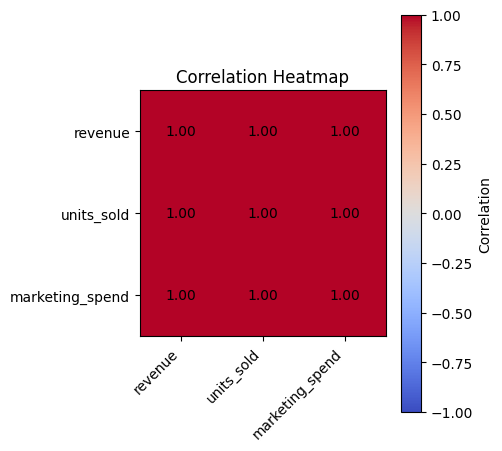

In [18]:
# Step 2: visualize it with imshow (treats the matrix like an image)
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# Label the axes with column names
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

# Write the actual correlation values on top of each cell
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

ax.set_title("Correlation Heatmap")
plt.colorbar(im, label="Correlation")
plt.tight_layout()
plt.show()

**How to read it:** values near +1 (red here) mean the two variables move together
strongly. Values near -1 (blue) mean one goes up as the other goes down. Values near 0
mean little to no linear relationship. The diagonal is always 1.0 (a variable is perfectly
correlated with itself).

**Practice 5**
Add a 4th random column to `numeric_cols` (e.g. `np.random.rand(6) * 100`) and regenerate
the heatmap. Which pair of columns is most strongly correlated now?

In [19]:
# Your practice code here


## 6. SQL Basics — SELECT, WHERE, GROUP BY, JOIN

We'll use Python's built-in `sqlite3` module to create a real (temporary, in-memory)
database, so you can practice actual SQL syntax, not just pandas equivalents.

In [20]:
# Create an in-memory SQLite database and a connection
conn = sqlite3.connect(":memory:")   # ":memory:" -> database exists only in RAM, for this session
cursor = conn.cursor()

# Create a table
cursor.execute('''
CREATE TABLE employees (
    id INTEGER PRIMARY KEY,
    name TEXT,
    department TEXT,
    salary INTEGER
)
''')

# Insert some rows
employees_data = [
    (1, "Amit", "Engineering", 55000),
    (2, "Priya", "Marketing", 62000),
    (3, "Rahul", "Engineering", 48000),
    (4, "Sneha", "HR", 51000),
    (5, "Vikram", "Engineering", 71000),
]
cursor.executemany("INSERT INTO employees VALUES (?, ?, ?, ?)", employees_data)
conn.commit()
print("Table created and populated.")

Table created and populated.


In [21]:
# SELECT: retrieve columns/rows
cursor.execute("SELECT name, salary FROM employees")
results = cursor.fetchall()
for row in results:
    print(row)

('Amit', 55000)
('Priya', 62000)
('Rahul', 48000)
('Sneha', 51000)
('Vikram', 71000)


In [22]:
# WHERE: filter rows (same idea as pandas boolean filtering)
cursor.execute("SELECT name, department, salary FROM employees WHERE salary > 50000")
for row in cursor.fetchall():
    print(row)

('Amit', 'Engineering', 55000)
('Priya', 'Marketing', 62000)
('Sneha', 'HR', 51000)
('Vikram', 'Engineering', 71000)


In [23]:
# WHERE with AND / OR
cursor.execute('''
SELECT name, department, salary
FROM employees
WHERE department = 'Engineering' AND salary > 50000
''')
for row in cursor.fetchall():
    print(row)

('Amit', 'Engineering', 55000)
('Vikram', 'Engineering', 71000)


In [24]:
# GROUP BY: aggregate rows into groups (same idea as pandas groupby)
cursor.execute('''
SELECT department, AVG(salary) as avg_salary, COUNT(*) as headcount
FROM employees
GROUP BY department
''')
for row in cursor.fetchall():
    print(row)

('Engineering', 58000.0, 3)
('HR', 51000.0, 1)
('Marketing', 62000.0, 1)


In [25]:
# ORDER BY + LIMIT: sorting and limiting results
cursor.execute('''
SELECT name, salary
FROM employees
ORDER BY salary DESC
LIMIT 3
''')
for row in cursor.fetchall():
    print(row)

('Vikram', 71000)
('Priya', 62000)
('Amit', 55000)


In [26]:
# JOIN: combine data from two tables using a shared key
cursor.execute('''
CREATE TABLE departments (
    dept_name TEXT,
    manager TEXT
)
''')
dept_data = [
    ("Engineering", "Meera Rao"),
    ("Marketing", "Sanjay Iyer"),
    ("HR", "Divya Nair"),
]
cursor.executemany("INSERT INTO departments VALUES (?, ?)", dept_data)
conn.commit()

# INNER JOIN: match employees.department to departments.dept_name
cursor.execute('''
SELECT employees.name, employees.salary, departments.manager
FROM employees
JOIN departments ON employees.department = departments.dept_name
''')
for row in cursor.fetchall():
    print(row)

('Amit', 55000, 'Meera Rao')
('Priya', 62000, 'Sanjay Iyer')
('Rahul', 48000, 'Meera Rao')
('Sneha', 51000, 'Divya Nair')
('Vikram', 71000, 'Meera Rao')


**Practice 6**
Write a query that joins `employees` and `departments`, filters for salary > 50000, and
orders the results by salary descending.

In [27]:
# Your practice code here


## 7. Connecting Python with Databases

The real power comes from combining SQL with pandas: run a query, get the result straight
into a DataFrame for analysis or plotting.

In [28]:
# pandas can run a SQL query directly against a connection and return a DataFrame
query = "SELECT * FROM employees"
emp_df = pd.read_sql(query, conn)
emp_df

,id,name,department,salary
0,1,Amit,Engineering,55000
1,2,Priya,Marketing,62000
2,3,Rahul,Engineering,48000
3,4,Sneha,HR,51000
4,5,Vikram,Engineering,71000


In [29]:
# You can write more complex queries too
query = '''
SELECT department, AVG(salary) as avg_salary
FROM employees
GROUP BY department
ORDER BY avg_salary DESC
'''
dept_summary = pd.read_sql(query, conn)
dept_summary

,department,avg_salary
0,Marketing,62000.0
1,Engineering,58000.0
2,HR,51000.0


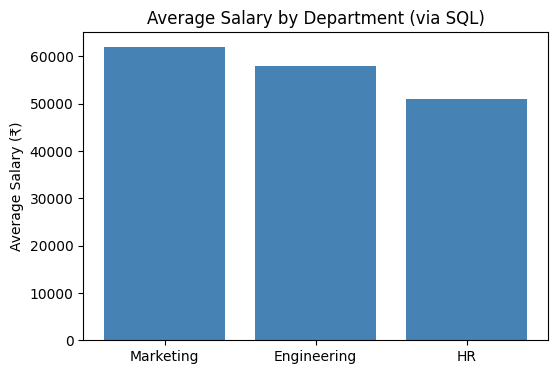

In [30]:
# ...and immediately plot the result
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dept_summary["department"], dept_summary["avg_salary"], color="steelblue")
ax.set_title("Average Salary by Department (via SQL)")
ax.set_ylabel("Average Salary (₹)")
plt.show()

In [31]:
# You can also go the OTHER direction: push a DataFrame INTO a SQL table
new_data = pd.DataFrame({
    "id": [6, 7],
    "name": ["Anita", "Karan"],
    "department": ["Marketing", "HR"],
    "salary": [58000, 49000]
})
new_data.to_sql("employees", conn, if_exists="append", index=False)

# Confirm it was added
pd.read_sql("SELECT * FROM employees", conn)

,id,name,department,salary
0,1,Amit,Engineering,55000
1,2,Priya,Marketing,62000
2,3,Rahul,Engineering,48000
3,4,Sneha,HR,51000
4,5,Vikram,Engineering,71000
5,6,Anita,Marketing,58000
6,7,Karan,HR,49000


In [32]:
# Always close the connection when you're done with a real database
conn.close()
print("Connection closed.")

Connection closed.


**Note on real databases:** the same `sqlite3` pattern works for local file-based
databases too — just change `sqlite3.connect(":memory:")` to `sqlite3.connect("my_data.db")`.
For production databases like PostgreSQL or MySQL, you'd use a driver such as `psycopg2` or
`mysql-connector-python`, but the pandas side (`pd.read_sql`, `df.to_sql`) works the same way.

**Practice 7 (mini end-to-end task)**
1. Create a new in-memory SQLite database.
2. Load the `sales` DataFrame from Section 2 into a table called `sales`.
3. Use `pd.read_sql` to query total revenue where `units_sold > 150`.
4. Plot the result as a bar chart.

In [33]:
# Your practice code here


## Summary

You've now covered the core visualization toolkit (Matplotlib: line, bar, histogram,
scatter, heatmap) and the core SQL toolkit (SELECT, WHERE, GROUP BY, ORDER BY, JOIN) plus
how to connect the two worlds using pandas + sqlite3. This combination — query the data,
then visualize it — is one of the most common real-world data analysis workflows.